In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

In [3]:
df = pd.read_csv("survey_results_public.csv")

print("Shape:", df.shape)

Shape: (49191, 172)


/var/folders/p8/0jf8lzc13qbdb5t_x9dhxprh0000gn/T/ipykernel_12851/2907406380.py:1: DtypeWarning: Columns (56,74,92,97,98,105,109,110,132,162,165) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("survey_results_public.csv")


In [5]:
TARGET = "AIAcc"

# these are the columns we’ll try to use (some may not exist depending on version)
FEATURES = [
    "Age",
    "YearsCode",
    "YearsCodePro",
    "DevType",
    "Employment",
    "RemoteWork",
    "OrgSize",
    "Country",
    "EdLevel",
    "LearnCode",
    "AIThreat",
    "AISent",
    "AISelect"
]

FEATURES = [f for f in FEATURES if f in df.columns]

df = df[[TARGET] + FEATURES].copy()
df = df[df[TARGET].notna()]

print("Using features:", FEATURES)

Using features: ['Age', 'YearsCode', 'DevType', 'Employment', 'RemoteWork', 'OrgSize', 'Country', 'EdLevel', 'LearnCode', 'AIThreat', 'AISent', 'AISelect']


In [7]:
# 1 = distrust, 0 = everything else
df["y"] = df[TARGET].astype(str).str.contains(
    "Somewhat distrust|Highly distrust",
    case=False,
    na=False
).astype(int)

print(df["y"].value_counts())

y
0    18079
1    15218
Name: count, dtype: int64


In [9]:
# turn text-based experience values into numeric
def clean_years(col):
    return pd.to_numeric(
        col.replace({
            "Less than 1 year": "0.5",
            "More than 50 years": "50"
        }),
        errors="coerce"
    )

for col in ["YearsCode", "YearsCodePro"]:
    if col in df.columns:
        df[col] = clean_years(df[col])

In [11]:
# fill missing values (median for numeric, label for categorical)
numeric_cols = df[FEATURES].select_dtypes(include=np.number).columns.tolist()
categorical_cols = [c for c in FEATURES if c not in numeric_cols]

# numeric = median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# categorical = "missing"
for col in categorical_cols:
    df[col] = df[col].fillna("Missing").astype(str)

In [13]:
# prevent dummy columns
def reduce_categories(series, min_count=100):
    counts = series.value_counts()
    keep = counts[counts >= min_count].index
    return series.where(series.isin(keep), "Other")

for col in categorical_cols:
    df[col] = reduce_categories(df[col])

In [15]:
X = pd.get_dummies(df[FEATURES], drop_first=True)
y = df["y"].values

print("Encoded shape:", X.shape)

Encoded shape: (33297, 167)


In [17]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
# standardize
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
# simple MLP with ReLU hidden layers and sigmoid output
def build_model(input_dim, hidden_layers, lr):
    model = keras.Sequential()
    
    model.add(layers.Input(shape=(input_dim,)))
    
    for units in hidden_layers:
        model.add(layers.Dense(units, activation="relu"))
    
    model.add(layers.Dense(1, activation="sigmoid"))
    
    optimizer = keras.optimizers.SGD(learning_rate=lr)
    
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [23]:
# trying different architectures and learning rates
architectures = [
    [32],
    [64],
    [64, 32],
    [128, 64]
]

learning_rates = [0.01, 0.001]

best_model = None
best_loss = np.inf
best_config = None
best_history = None

for arch in architectures:
    for lr in learning_rates:
        print(f"Training: {arch}, lr={lr}")
        
        model = build_model(X_train.shape[1], arch, lr)
        
        history = model.fit(
            X_train, y_train,
            epochs=50,
            batch_size=128,
            validation_split=0.2,
            verbose=0
        )
        
        val_loss = min(history.history["val_loss"])
        
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = model
            best_config = (arch, lr)
            best_history = history

print("\nBest config:", best_config)

Training: [32], lr=0.01


2026-04-14 17:12:26.746290: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-04-14 17:12:26.746638: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-14 17:12:26.746656: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-14 17:12:26.747022: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-14 17:12:26.747353: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-14 17:12:27.230226: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Training: [32], lr=0.001
Training: [64], lr=0.01
Training: [64], lr=0.001
Training: [64, 32], lr=0.01
Training: [64, 32], lr=0.001
Training: [128, 64], lr=0.01
Training: [128, 64], lr=0.001

Best config: ([64], 0.01)


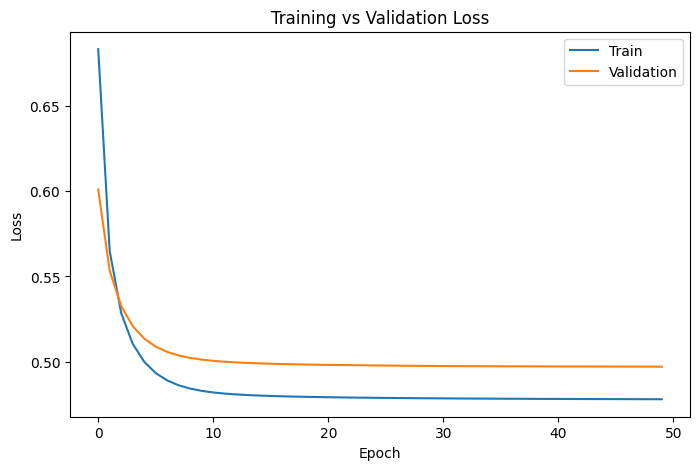

In [25]:
# visualize training vs validation loss
plt.figure(figsize=(8,5))
plt.plot(best_history.history["loss"], label="Train")
plt.plot(best_history.history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

Training and validation loss both decrease quickly and stabilize after the first few epochs. The gap between the two curves remains small, suggesting that the model is not heavily overfitting and generalizes reasonably well to unseen data.

In [27]:
# generate predicted probabilities and classes
y_pred_prob = best_model.predict(X_test).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.83      0.79      3616
           1       0.77      0.66      0.71      3044

    accuracy                           0.76      6660
   macro avg       0.76      0.75      0.75      6660
weighted avg       0.76      0.76      0.75      6660



The model achieves an overall accuracy of approximately 76%, with balanced performance across both classes.

For the distrust class (1), the model achieves a precision of 0.77 and recall of 0.66, indicating that while predictions of distrust are generally accurate, the model misses a portion of true distrust cases.

For the non-distrust class (0), recall is higher at 0.83, meaning the model is more effective at identifying developers who do not express distrust.

In [31]:
# compute overall classification quality
auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC:", auc)

ROC-AUC: 0.8313692230036166


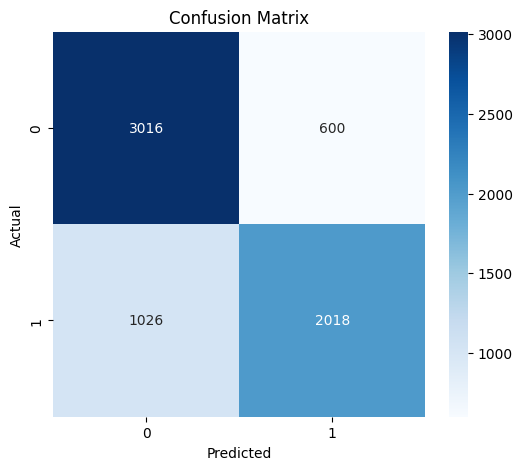

In [33]:
# show correct vs incorrect predictions
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

The confusion matrix shows that the model correctly classifies a large number of non-distrust cases (3016 true negatives) and distrust cases (2018 true positives).

However, there are 1026 false negatives, indicating that a notable portion of developers who distrust AI are incorrectly classified as not distrustful. This aligns with the lower recall observed for the distrust class.

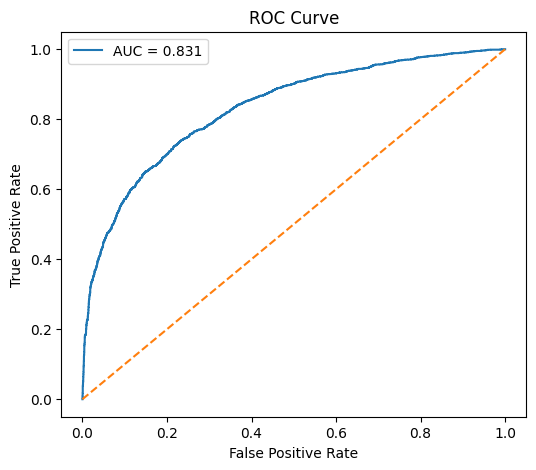

In [35]:
# plot tradeoff between true and false positives
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

The model achieves an ROC-AUC of 0.831, indicating strong overall classification performance.

This suggests that the model is effective at distinguishing between developers who distrust AI and those who do not, even across different classification thresholds.

Overall, the neural network demonstrates that distrust in AI-generated output is reasonably predictable using developer characteristics and AI-related perception variables. The relatively strong AUC indicates that meaningful patterns exist in the data, while the lower recall for the distrust class suggests that these patterns are not perfectly separable. This supports the idea that distrust is influenced by multiple interacting factors rather than a single dominant variable.